In [1]:
from src import *

In [2]:
def log_target0(x):
    return -0.5 * x**2
def log_target1(x, D=4):
    return -0.5 * (x - D)**2
def log_target_path(x, path):
    return (1-path) * log_target0(x) + path * log_target1(x)
def grad_log_target_path(x):
    return log_target1(x, D=4) - log_target0(x)

- Initialisation of the hyperparameters 

In [3]:
L = 20  # 0, 0.1, ..., 1.0
nrep = 100
sigmaq = 1
lag = 1
lambda_grid = np.arange(0, L + 1) / L # uniform grid of lambda values in [0, 1]

### Tuning of the parameters $k_\lambda$ and $m_\lambda$ over a uniform grid of size $L$

mk tunning: 100%|██████████| 21/21 [00:00<00:00, 77.12it/s]


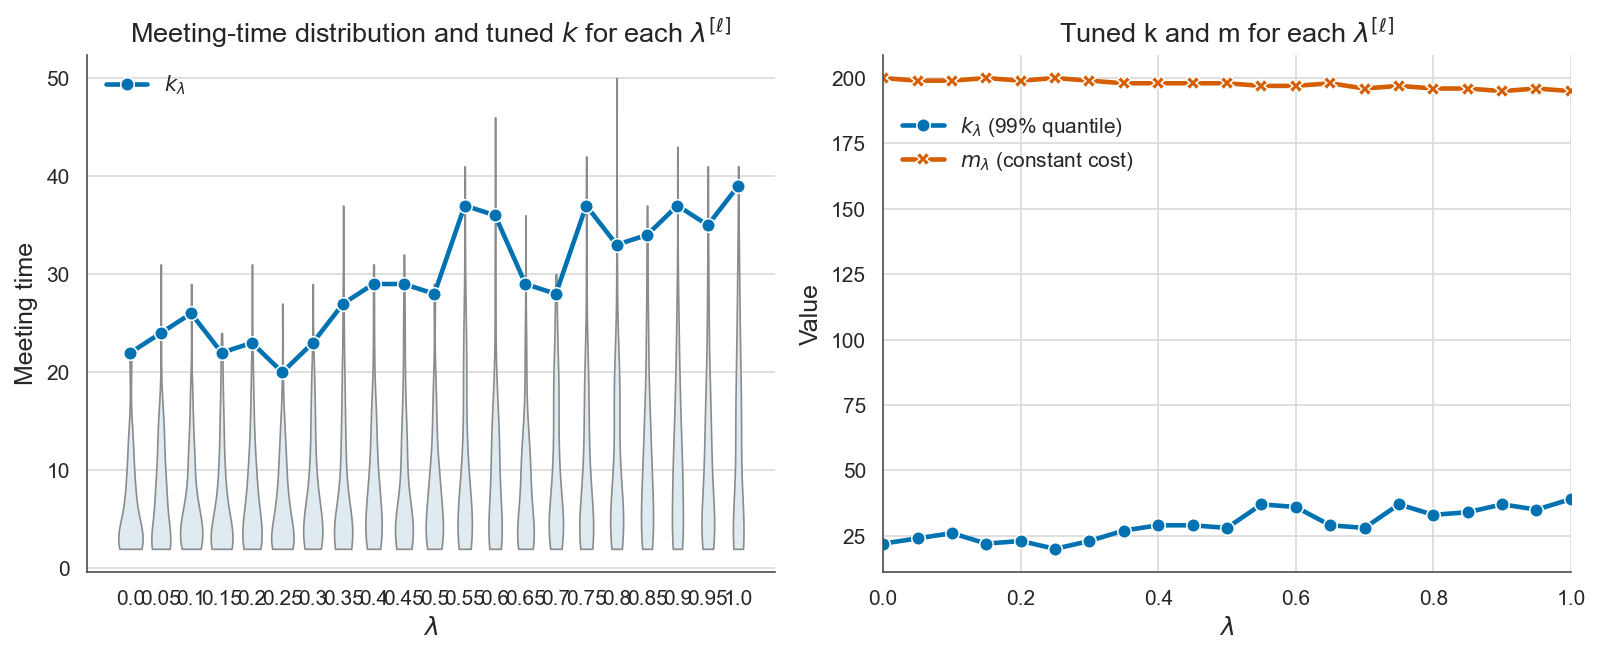

In [4]:
km_grid = tune_km_grid(lambda_grid, lag = lag, sigmaq = sigmaq, log_target_path = log_target_path, nrep = nrep)
plot_km_grid(lambda_grid, lag = lag, sigmaq = sigmaq, log_target_path = log_target_path, nrep = nrep)

### Variance of the UMCMC estimator and the second moment over the grid 
- $\hat{E}(\lambda)$ is the UMCMC of the expectation $\mathbb{E}_{\pi_\lambda}[\nabla_\lambda \log \pi_\lambda]$

Final estimation: 100%|██████████| 21/21 [00:03<00:00,  5.53it/s]


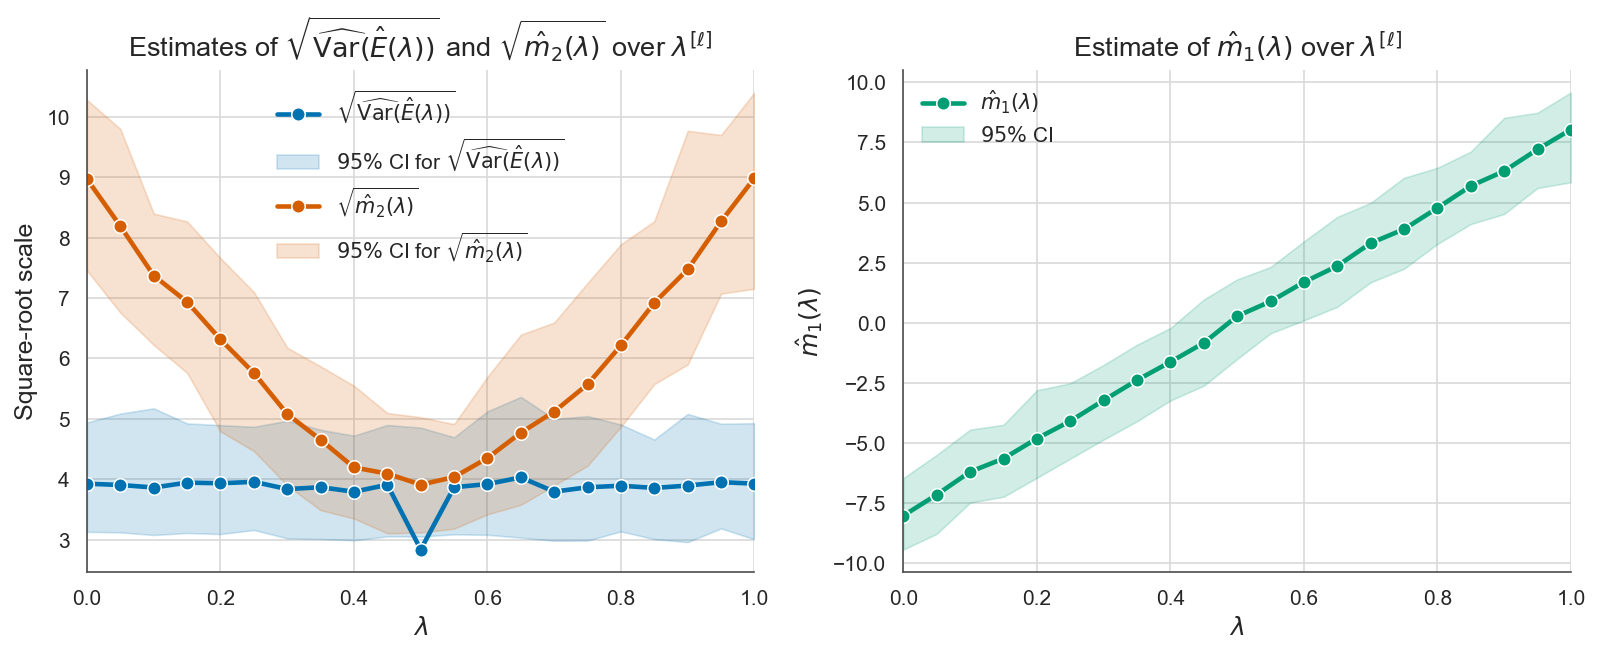

In [5]:
k_grid, m_grid = km_grid["k_grid"], km_grid["m_grid"]
plot_estimate_mom(lambda_grid, k_grid, m_grid, nrep, sigmaq, lag, log_target_path, grad_log_target_path)

### Comparaison of IS and Startified based estimator

- Stratified estimator

In [6]:
L = 20

- IS estimator

In [7]:
res = estimate_mom(lambda_grid, k_grid, m_grid, nrep, sigmaq, lag, log_target_path, grad_log_target_path)
sqrt_m2 = np.sqrt(res["m2"])

Final estimation: 100%|██████████| 21/21 [00:03<00:00,  5.54it/s]


In [8]:
M_grid = np.array([20, 50, 100, 500, 1000, 5000, 10000]) #, 220, 250, 270, 290, 320, 350, 380, 500, 1000]) # 500, 1000, 2000, 3000, 5000
estimator = lambda lam: uestimator_given_lambda(lam, lambda_grid, k_grid, m_grid, sigmaq, lag, log_target_path, grad_log_target_path)

df_results = compare_mse_budget_grid_plot(
    L=L,
    M_grid=M_grid,
    estimator=estimator,
    sqrt_m2=sqrt_m2,
    true_value=0,
    nrep=10,
    n_samples_per_bin=10
)




100%|██████████| 7/7 [07:33<00:00, 64.85s/it] 


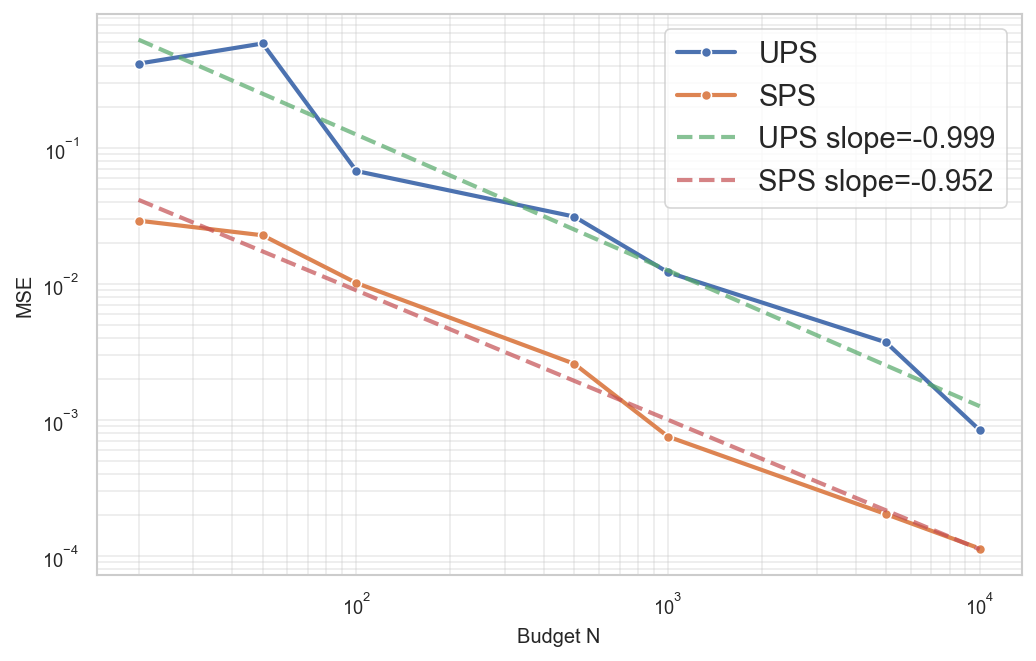

Estimated log-log slopes:
- UPS: -0.999
- SPS: -0.952


In [9]:

sns.set_theme(style="whitegrid", context="paper")

plt.figure(figsize=(7, 4.5), dpi=150)

sns.lineplot(
    data=df_results,
    x="M",
    y="mse",
    hue="estimator",
    marker="o",
    linewidth=2
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Budget N")
plt.ylabel("MSE")
plt.grid(True, which="both", alpha=0.4)

slopes = {}
trend_handles = []
for estimator_name in df_results["estimator"].unique():
    df_est = df_results[df_results["estimator"] == estimator_name]
    logM = np.log(df_est["M"].astype(float).values)
    logmse = np.log(df_est["mse"].astype(float).values)
    slope, intercept = np.polyfit(logM, logmse, 1)
    slopes[estimator_name] = slope

    # tracer la droite de tendance en échelle log-log
    x_line = np.linspace(df_est["M"].min(), df_est["M"].max(), 100)
    y_line = np.exp(intercept + slope * np.log(x_line))
    handle, = plt.plot(
        x_line,
        y_line,
        linestyle="--",
        linewidth=2,
        alpha=0.7,
        label=f"{estimator_name} slope={slope:.3f}"
    )
    trend_handles.append(handle)

# Mettre à jour la légende avec les tendances et les traces existantes
plt.legend(fontsize=14)

plt.tight_layout()
plt.show()

print("Estimated log-log slopes:")
for estimator_name, slope in slopes.items():
    print(f"- {estimator_name}: {slope:.3f}")

- Box Plots 

In [8]:
M = 50
estimator = lambda lam: uestimator_given_lambda(lam, lambda_grid, k_grid, m_grid, sigmaq, lag, log_target_path, grad_log_target_path)

budget = build_budget(
            L=L,
            M=M,
            estimator=estimator,
            n_samples_per_bin=10
        )
estimators = [lambda : q_unbiased_estimator(L, M, estimator, sqrt_m2), lambda : optimal_startified_estimator(L, estimator, budget)]

Computing budget: 100%|██████████| 20/20 [00:00<00:00, 67.41it/s]


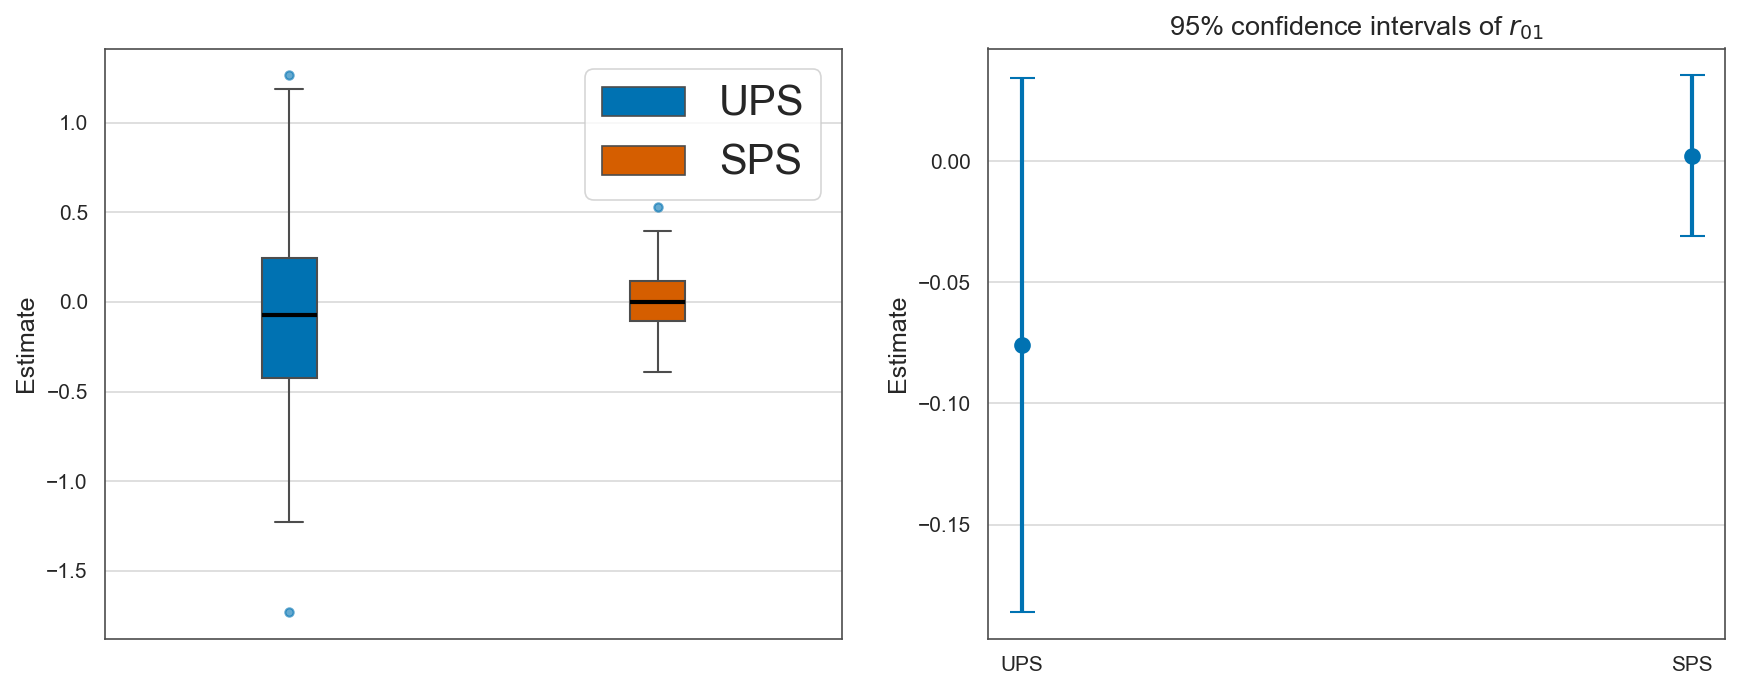

UPS: CI = [-0.186067, 0.034454], length = 0.220521
SPS: CI = [-0.030764, 0.035472], length = 0.066236


{'samples': [array([-0.40638522, -0.81250997, -0.147837  ,  0.11336371, -0.1106656 ,
         -0.41757331,  0.29465877, -0.30540295, -0.02492371, -0.81882409,
         -0.32565705, -0.16327064,  0.13622341,  0.03930395, -0.28198849,
          0.34775053, -0.08424653,  0.21069168,  0.47960367, -0.9002014 ,
         -0.20116982,  0.53173444,  0.57056918, -0.56338679, -0.14744824,
          0.78775792, -0.56328374,  0.18439646, -0.13557684,  0.0554228 ,
         -0.46238145, -0.42001751,  0.73242782,  0.25764304, -0.59314686,
          0.06106433,  1.26422527, -1.08381512, -0.38360944,  0.37367861,
         -0.31692989, -0.05284433, -0.47747887,  0.91951645, -0.5050592 ,
         -0.32667823,  0.1659511 , -0.27238007, -0.07125332,  1.13454033,
         -0.05206581, -0.05584907,  0.42329142, -0.17767482,  0.26234229,
         -0.89906551,  0.67908272,  0.1330821 , -0.57284134,  0.59134601,
          0.02344751,  0.24239989, -1.22573355,  0.82879862, -0.04518707,
         -1.09520589,  0.88

In [9]:
plot_estimators_box_CI(
    estimators,
    labels = ['UPS', 'SPS'],
    nrep=100,
    ci_level=0.95,
    figsize=(12, 5),
)